# Practical No: 1
**Subject:** Deep Learning

**Problem Statement:** Install and configure TensorFlow/Keras in Google Colab. Perform data preprocessing, normalization, train-test split, and visualization on a sample dataset.

**Dataset:** Fashion-MNIST (via KaggleHub)

In [1]:
!pip install -q kagglehub mlxtend

In [2]:
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.data import loadlocal_mnist
from sklearn.model_selection import train_test_split

In [3]:
# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fashionmnist' dataset.
Path to dataset files: /kaggle/input/fashionmnist


In [4]:
print("Files in dataset:")

for file in os.listdir(path):
    print(file)

Files in dataset:
t10k-labels-idx1-ubyte
t10k-images-idx3-ubyte
fashion-mnist_test.csv
fashion-mnist_train.csv
train-labels-idx1-ubyte
train-images-idx3-ubyte


In [6]:
import tensorflow as tf

# Load Fashion-MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Combine training and testing data
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)

print("Images Shape:", X.shape)
print("Labels Shape:", y.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Images Shape: (70000, 28, 28)
Labels Shape: (70000,)


In [7]:
X = X.astype("float32") / 255.0

print("Minimum Pixel Value:", X.min())
print("Maximum Pixel Value:", X.max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (56000, 28, 28)
Testing Data : (14000, 28, 28)


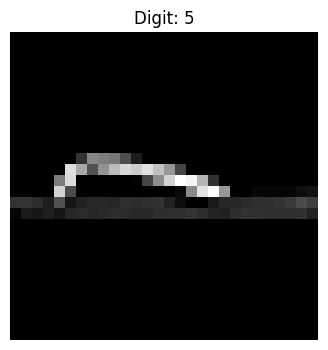

In [9]:
plt.figure(figsize=(4,4))
plt.imshow(X_train[0].reshape(28,28), cmap="gray")
plt.title(f"Digit: {y_train[0]}")
plt.axis("off")
plt.show()

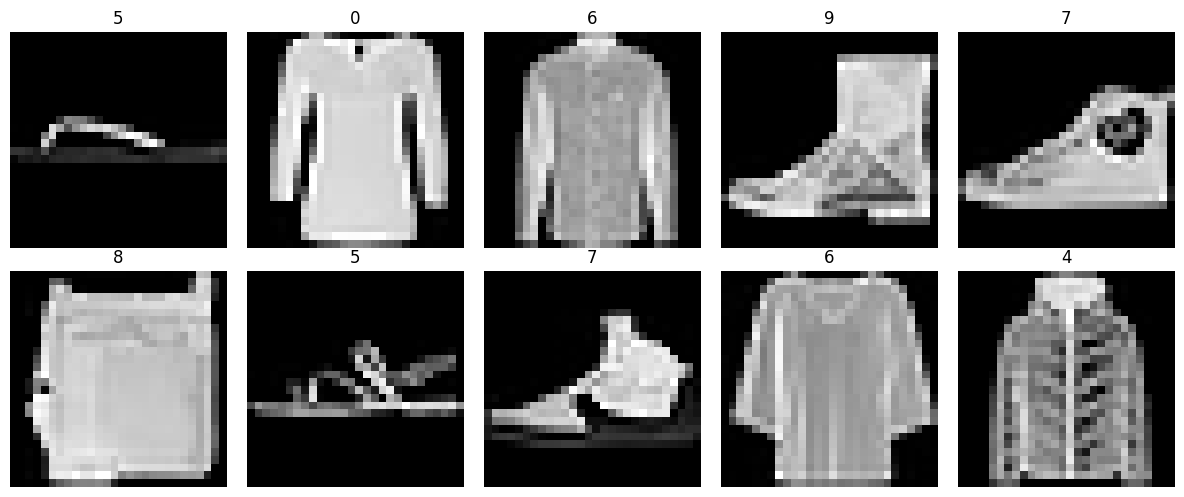

In [10]:
plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

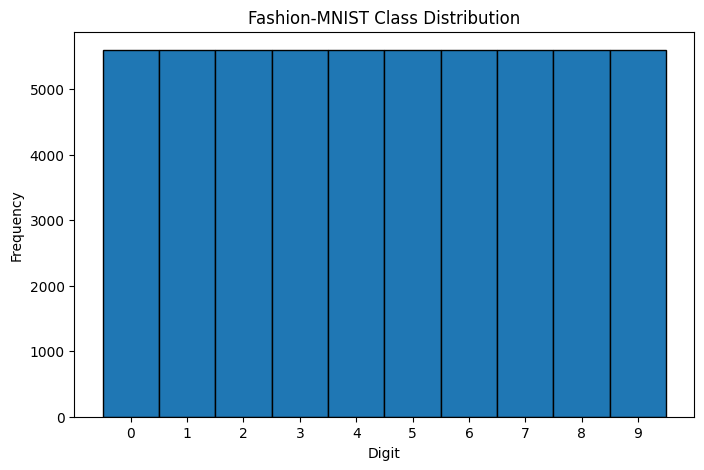

In [11]:
plt.figure(figsize=(8,5))

plt.hist(y_train, bins=np.arange(11)-0.5, edgecolor="black")

plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Frequency")
plt.title("Fashion-MNIST Class Distribution")

plt.show()

In [12]:
print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

print("Pixel Value Range :", X_train.min(), "to", X_train.max())

Training Images : (56000, 28, 28)
Testing Images  : (14000, 28, 28)
Training Labels : (56000,)
Testing Labels  : (14000,)
Pixel Value Range : 0.0 to 1.0
